# W1 — бюджет неопределённости профиля стенки

Отчёт над batch-артефактом `results/measurement_uncertainty_budget_w1`. Числа берутся только оттуда.

W1 отвечает на один вопрос: насколько итоговое число программы-минимума двигается от произвольных решений конвейера, а не от анатомии. Фазы между собой **не сравниваются** — парные дельты остаются заблокированными Gate 1. Протокол, пять семейств возмущений и пороги `1.0/2.5 мм` заморожены в `configs/measurement_uncertainty_budget_w1.json` до вычисления; обоснование — в `docs/WALL_MEASUREMENT_UNCERTAINTY_W1.md`.

**Техническое воспроизведение, 14.09.2026.** Ноутбук сохраняет историческую постановку и ограничения. Повторное исполнение проверяет расчёты и отображение; оно не меняет научный статус ветки. Тяжёлые результаты читаются из сохранённых пакетов с исходными проверками целостности. Источники и конфигурации используются из этой папки проекта.

In [1]:
# Portable execution support; scientific sources remain in this checkout.
import os
import sys
from pathlib import Path
_start = Path(os.environ.get("BREATH_NOTEBOOK_DIR", Path.cwd())).resolve()
_support = next((folder for parent in (_start, *_start.parents)
                 for folder in (parent, parent / "notebooks", parent / "breath geometry/notebooks")
                 if (folder / "execution_support.py").is_file()), None)
if _support is None:
    raise FileNotFoundError("Не найден notebooks/execution_support.py")
sys.path.insert(0, str(_support))
from execution_support import roots, copdgene_case_dir, lungct_input
REPO_ROOT, ARTIFACT_ROOT = roots()
repo_root = REPO_ROOT


In [2]:
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RESULT_DIR = ARTIFACT_ROOT / "results/measurement_uncertainty_budget_w1"


def sha256(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest().upper()


manifest = json.loads((RESULT_DIR / "manifest.json").read_text(encoding="utf-8"))
summary = json.loads((RESULT_DIR / "summary.json").read_text(encoding="utf-8"))
variants = pd.read_csv(RESULT_DIR / "variants.csv")
families = pd.read_csv(RESULT_DIR / "families.csv")

checks = {
    "config": sha256(REPO_ROOT / manifest["config"]["path"]) == manifest["config"]["sha256"],
    "variants": sha256(RESULT_DIR / "variants.csv") == manifest["variants_sha256"],
    "families": sha256(RESULT_DIR / "families.csv") == manifest["families_sha256"],
    "summary": sha256(RESULT_DIR / "summary.json") == manifest["summary_sha256"],
}
print(manifest["budget_version"], summary["dataset_id"], summary["subject_id"])
print("checksums:", checks)
assert all(checks.values())
assert summary["cross_phase_comparison"]["performed"] is False

wall-measurement-uncertainty-budget-w1 dirlab_copdgene copd1
checksums: {'config': True, 'variants': True, 'families': True, 'summary': True}


## Что дало каждое возмущение

Каждая строка — одна перенастройка конвейера на той же самой фазе и той же анатомии.

In [3]:
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)
columns = [
    "phase",
    "family",
    "variant_label",
    "valid_count",
    "valid_fraction",
    "median_thickness_mm",
    "median_fat_mm",
    "median_muscle_mm",
]
variants[columns].round(4)

,phase,family,variant_label,valid_count,valid_fraction,median_thickness_mm,median_fat_mm,median_muscle_mm
0,fixed,body_threshold,body_hu=-325,3304,0.5060,35.8412,10.4479,18.3317
1,fixed,body_threshold,body_hu=-300,3305,0.5062,35.8003,10.4386,18.3581
2,fixed,body_threshold,body_hu=-275,3304,0.5060,35.7511,10.4185,18.3575
3,fixed,lung_threshold,air_hu=-425,3292,0.4965,35.8490,10.4406,17.9975
4,fixed,lung_threshold,air_hu=-400,3305,0.5062,35.8003,10.4386,18.3581
5,fixed,lung_threshold,air_hu=-375,3314,0.5160,35.6787,10.4419,18.3275
6,fixed,tissue_window,fat_upper=-40,3305,0.5062,35.8003,9.6669,19.2139
7,fixed,tissue_window,fat_upper=-30,3305,0.5062,35.8003,10.4386,18.3581
8,fixed,tissue_window,fat_upper=-20,3305,0.5062,35.8003,11.7246,17.1777
9,fixed,surface_sampling,offset=0.000,3305,0.5062,35.8003,10.4386,18.3581


## Полуразмах по семействам

`half_range = (max - min) / 2` по вариантам одного семейства. Общий бюджет — корень из суммы квадратов, семейства считаются независимыми.

In [4]:
thickness = families[families["measurand"] == "median_thickness_mm"]
table = thickness.pivot_table(index="family", columns="phase", values="half_range")
combined = pd.DataFrame(
    {row["phase"]: row["combined_half_range"] for row in summary["phases"]}
).round(4)
print("half-range of median_thickness_mm, mm")
display(table.round(4))
print("\ncombined half-range per measurand, mm")
display(combined)

half-range of median_thickness_mm, mm


phase,fixed,moving
family,,
body_threshold,0.0450,0.0421
grid_jitter,0.0477,0.1214
lung_threshold,0.0852,0.0213
surface_sampling,0.1815,0.0744
tissue_window,0.0000,0.0000



combined half-range per measurand, mm


,fixed,moving
median_thickness_mm,0.2109,0.1500
median_soft_tissue_mm,0.1864,0.1809
median_fat_mm,1.0292,0.7691
median_muscle_mm,1.1035,0.7971
valid_fraction,0.0212,0.0232


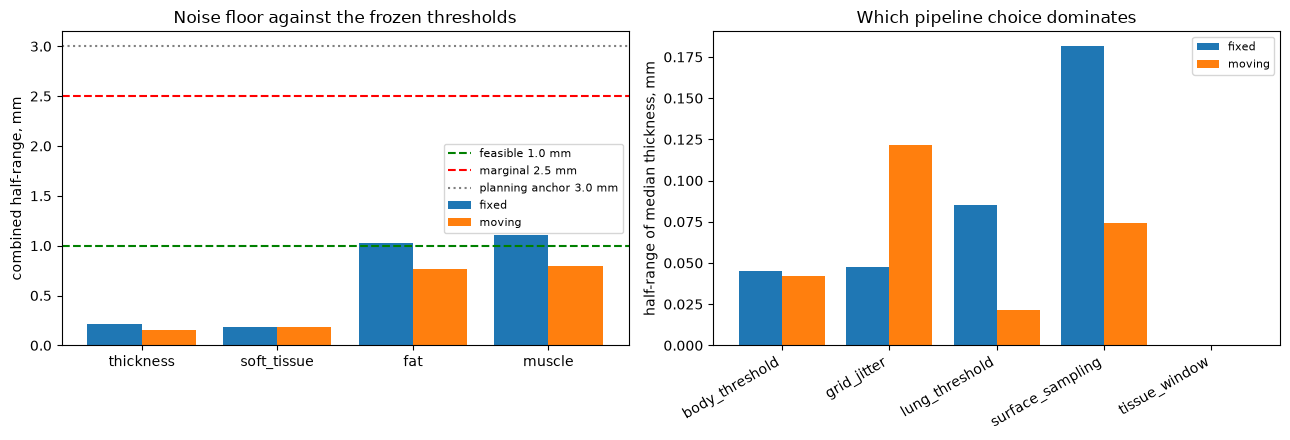

In [5]:
thresholds = summary["thresholds"]
measurands = ["median_thickness_mm", "median_soft_tissue_mm", "median_fat_mm", "median_muscle_mm"]
phases = [row["phase"] for row in summary["phases"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

width = 0.8 / len(phases)
positions = np.arange(len(measurands))
for index, row in enumerate(summary["phases"]):
    values = [row["combined_half_range"][name] for name in measurands]
    axes[0].bar(positions + index * width, values, width, label=row["phase"])
axes[0].axhline(thresholds["feasible_max_mm"], color="green", ls="--", label="feasible 1.0 mm")
axes[0].axhline(thresholds["marginal_max_mm"], color="red", ls="--", label="marginal 2.5 mm")
axes[0].axhline(
    thresholds["target_resolvable_effect_mm"],
    color="grey",
    ls=":",
    label="planning anchor 3.0 mm",
)
axes[0].set_xticks(positions + width * (len(phases) - 1) / 2)
axes[0].set_xticklabels([name.replace("median_", "").replace("_mm", "") for name in measurands])
axes[0].set_ylabel("combined half-range, mm")
axes[0].set_title("Noise floor against the frozen thresholds")
axes[0].legend(fontsize=8)

order = sorted(thickness["family"].unique())
by_family = thickness.pivot_table(index="family", columns="phase", values="half_range")
positions = np.arange(len(order))
for index, phase in enumerate(phases):
    values = [
        float(by_family.loc[family, phase])
        for family in order
    ]
    axes[1].bar(positions + index * width, values, width, label=phase)
axes[1].set_xticks(positions + width * (len(phases) - 1) / 2)
axes[1].set_xticklabels(order, rotation=30, ha="right")
axes[1].set_ylabel("half-range of median thickness, mm")
axes[1].set_title("Which pipeline choice dominates")
axes[1].legend(fontsize=8)
fig.tight_layout()

## Структурная проверка реализации

Полная толщина задаётся только масками тела и лёгкого. Окно жир/мышца по построению не может её сдвинуть, но обязано сдвигать состав. Ненулевой полуразмах толщины у `tissue_window` означал бы дефект измерителя, а не свойство анатомии.

In [6]:
window = families[families["family"] == "tissue_window"]
invariant = window[window["measurand"] == "median_thickness_mm"]["half_range"].abs().max()
sensitivity = window[window["measurand"] == "median_fat_mm"]["half_range"].max()
print(f"tissue_window on total thickness: {invariant:.2e} mm (must be 0)")
print(f"tissue_window on fat:             {sensitivity:.4f} mm (must be > 0)")
assert invariant < 1e-9
assert sensitivity > 0.0
assert not any("IMPLEMENTATION WARNING" in note for note in summary["verdict"]["notes"])

tissue_window on total thickness: 0.00e+00 mm (must be 0)
tissue_window on fat:             1.0288 mm (must be > 0)


## Пространственный член

Для версии «3D-график» важна не общая медиана, а устойчивость числа локально. Бины — шесть направлений, скрещенные с тремя осевыми третями; разбиение зафиксировано по baseline и предварительно, отчётная карта требует рёберно-привязанной системы координат из Gate 1B.

In [7]:
spatial = pd.DataFrame(
    [{"phase": row["phase"], **entry} for row in summary["phases"] for entry in row["spatial"]]
)
display(spatial.round(4))
print(
    "worst p95 of the per-bin median shift: "
    f"{summary['verdict']['spatial_p95_worst_mm']:.4f} mm"
)

,phase,family,compared_bins,p95_abs_median_shift_mm,max_abs_median_shift_mm
0,fixed,body_threshold,26,0.4560,1.0467
1,fixed,lung_threshold,26,0.3089,1.1389
2,fixed,tissue_window,26,0.0000,0.0000
3,fixed,surface_sampling,26,0.9072,2.4895
4,fixed,grid_jitter,26,0.7355,2.4895
5,moving,body_threshold,24,0.6734,0.8244
6,moving,lung_threshold,24,0.3380,0.5631
7,moving,tissue_window,24,0.0000,0.0000
8,moving,surface_sampling,24,2.6261,3.0147
9,moving,grid_jitter,24,0.6642,1.0108


worst p95 of the per-bin median shift: 2.6261 mm


## Заранее заданное решение

In [8]:
verdict = summary["verdict"]
print(f"deciding phase:            {verdict['deciding_phase']}")
print(f"total thickness:           {verdict['thickness_classification']}")
print(f"soft tissue together:      {verdict['soft_tissue_classification']}")
print(f"fat separately:            {verdict['fat_classification']}")
print(f"muscle separately:         {verdict['muscle_classification']}")
print(f"fat and muscle separately allowed: {verdict['separate_fat_muscle_allowed']}")
print()
for note in verdict["notes"]:
    print("-", note)

assert verdict["thickness_classification"] in ("feasible", "marginal", "infeasible")
print("\nW1 compared no phases and produced no respiratory effect.")

deciding phase:            fixed
total thickness:           feasible
soft tissue together:      feasible
fat separately:            marginal
muscle separately:         marginal
fat and muscle separately allowed: True

- W1 measures pipeline reproducibility inside one phase; it is not accuracy against anatomical truth and it compares no phases.
- Families are combined as independent; correlated families would make the combined half-range an underestimate.
- target_resolvable_effect_mm=3 is a planning anchor, not a measured respiratory effect.

W1 compared no phases and produced no respiratory effect.
